In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Paso 1: URL del archivo JSON
url = 'https://www.datos.gov.co/resource/d7zw-hpf4.json?$limit=10000'  # Reemplaza con tu URL real

# Paso 2: Descargar el contenido JSON desde la URL
response = requests.get(url)
data_json = response.json()

# Paso 3: Convertir los datos JSON a un DataFrame
df = pd.json_normalize(data_json)  # o solo pd.DataFrame(data_json) según la estructura

# Paso 4: Crear y conectar a la base de datos SQLite
nombre_bd = 'Secuestros.db'
conn = sqlite3.connect(nombre_bd)

# Paso 5: Guardar el DataFrame como una tabla en SQLite
nombre_tabla = 'datos_json'
df.to_sql(nombre_tabla, conn, if_exists='replace', index=False)

# Paso 6: Cerrar conexión
conn.close()

print(f"Base de datos '{nombre_bd}' creada con la tabla '{nombre_tabla}' a partir del JSON.")







In [23]:
# -------------------------------
# 1. CONECTARSE A LA BASE DE DATOS
# -------------------------------
ruta_db = f'C:/Users/erick/primer_repo_izainea/Cuadernos/Secuestros.db'  # Cambia esto a tu ruta real
conn = sqlite3.connect(ruta_db)

# -------------------------------
# 2. CARGAR LA TABLA
# -------------------------------
nombre_tabla = 'datos_json'
df = pd.read_sql_query(f"SELECT * FROM {nombre_tabla};", conn)
conn.close()

# -------------------------------
# 3. PREPROCESAMIENTO
# -------------------------------
df['fecha_hecho'] = pd.to_datetime(df['fecha_hecho'], errors='coerce')
df['cantidad'] = pd.to_numeric(df['cantidad'], errors='coerce')
df['anio'] = df['fecha_hecho'].dt.year

# -------------------------------
# 4. ANÁLISIS ESTADÍSTICO
# -------------------------------

# Total de secuestros por año
por_anio = df.groupby('anio')['cantidad'].sum().reset_index()

# Total de secuestros por departamento
por_departamento = df.groupby('departamento')['cantidad'].sum().reset_index().sort_values(by='cantidad', ascending=False)

# Total de secuestros por tipo de delito
por_tipo = df.groupby('tipo_delito')['cantidad'].sum().reset_index().sort_values(by='cantidad', ascending=False)

# Top 10 municipios con más secuestros
por_municipio = df.groupby('municipio')['cantidad'].sum().reset_index().sort_values(by='cantidad', ascending=False).head(10)

In [17]:
# -------------------------------
# 3. CONSULTAS Y TABLAS EN FORMATO
# -------------------------------

# Tabla 1: Secuestros por Año
tabla_anio = df.groupby('anio')['cantidad'].sum().reset_index()
tabla_anio.columns = ['año', 'total_secuestros']
print("📆 Secuestros por Año:")
display(tabla_anio)




📆 Secuestros por Año:


,año,total_secuestros
0,1996,1038
1,1997,1624
2,1998,2860
3,1999,3205
4,2000,1273


In [18]:
# Tabla 2: Secuestros por Departamento
tabla_departamento = df.groupby('departamento')['cantidad'].sum().reset_index().sort_values(by='cantidad', ascending=False)
tabla_departamento.columns = ['departamento', 'total_secuestros']
print("📍 Secuestros por Departamento:")
display(tabla_departamento)



📍 Secuestros por Departamento:


,departamento,total_secuestros
1,ANTIOQUIA,1992
11,CESAR,833
26,SANTANDER,737
29,VALLE DEL CAUCA,686
22,NORTE DE SANTANDER,587
5,BOLIVAR,489
20,META,480
4,BOGOTA D.C.,433
14,CUNDINAMARCA,405
19,MAGDALENA,383


In [19]:
# Tabla 3: Secuestros por Tipo de Delito
tabla_tipo = df.groupby('tipo_delito')['cantidad'].sum().reset_index().sort_values(by='cantidad', ascending=False)
tabla_tipo.columns = ['tipo_delito', 'total_secuestros']
print("🔍 Secuestros por Tipo de Delito:")
display(tabla_tipo)



🔍 Secuestros por Tipo de Delito:


,tipo_delito,total_secuestros
0,SECUESTRO EXTORSIVO,8150
1,SECUESTRO SIMPLE,1850


In [20]:
# Tabla 4: Top 10 Municipios con más Secuestros
tabla_municipio = df.groupby('municipio')['cantidad'].sum().reset_index().sort_values(by='cantidad', ascending=False).head(10)
tabla_municipio.columns = ['municipio', 'total_secuestros']
print("🏙️ Top 10 Municipios con más Secuestros:")
display(tabla_municipio)



🏙️ Top 10 Municipios con más Secuestros:


,municipio,total_secuestros
79,BOGOTA D.C.,433
104,CALI,412
374,MEDELLIN,372
697,VALLEDUPAR,199
84,BUCARAMANGA,184
713,VILLAVICENCIO,153
588,SANTA MARTA,143
177,CUCUTA,124
64,BARRANCABERMEJA,115
511,RIONEGRO,95


In [21]:
# Tabla 5: Secuestros por Año y Tipo de Delito
tabla_anio_tipo = df.groupby(['anio', 'tipo_delito'])['cantidad'].sum().reset_index().sort_values(by=['anio', 'cantidad'], ascending=[True, False])
tabla_anio_tipo.columns = ['año', 'tipo_delito', 'total_secuestros']
print("📆🔍 Secuestros por Año y Tipo de Delito:")
display(tabla_anio_tipo)

📆🔍 Secuestros por Año y Tipo de Delito:


,año,tipo_delito,total_secuestros
0,1996,SECUESTRO EXTORSIVO,958
1,1996,SECUESTRO SIMPLE,80
2,1997,SECUESTRO EXTORSIVO,1470
3,1997,SECUESTRO SIMPLE,154
4,1998,SECUESTRO EXTORSIVO,2302
5,1998,SECUESTRO SIMPLE,558
6,1999,SECUESTRO EXTORSIVO,2587
7,1999,SECUESTRO SIMPLE,618
8,2000,SECUESTRO EXTORSIVO,833
9,2000,SECUESTRO SIMPLE,440


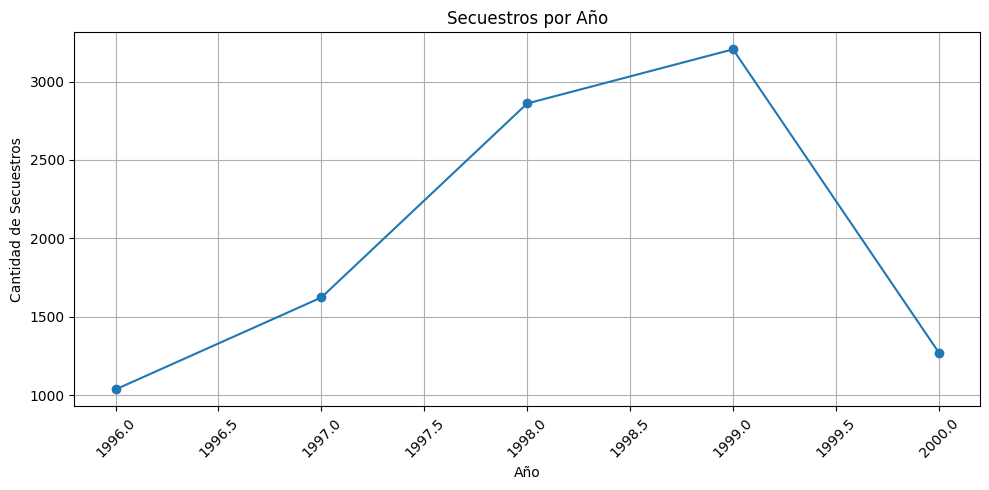

In [22]:

# -------------------------------
# 6. GRÁFICOS
# -------------------------------

# Gráfico 1: Secuestros por año
plt.figure(figsize=(10, 5))
plt.plot(por_anio['anio'], por_anio['cantidad'], marker='o')
plt.title('Secuestros por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad de Secuestros')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

